**Machine y Deep Learning**

Unidad 2
Práctica 1: Regresión Lineal Simple

*Facilitador: Dr. José Gabriel Rodríguez Rivas*

*Alumna: Carolina Alvarado Hernández*

Cargar datos y librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import gdown

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
#https://drive.google.com/file/d/1LgW2AmS3kPRIKnx_trLVPi_RjsjVjnT_/view?usp=drive_link
file_id = "1LgW2AmS3kPRIKnx_trLVPi_RjsjVjnT_"
url = f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)
print(df.head(10))

Mounted at /content/drive
   symboling  normalized-losses         make fuel-type aspiration  \
0          3                122  alfa-romero       gas        std   
1          3                122  alfa-romero       gas        std   
2          1                122  alfa-romero       gas        std   
3          2                164         audi       gas        std   
4          2                164         audi       gas        std   
5          2                122         audi       gas        std   
6          1                158         audi       gas        std   
7          1                122         audi       gas        std   
8          1                158         audi       gas      turbo   
9          2                192          bmw       gas        std   

  num-of-doors   body-style drive-wheels engine-location  wheel-base  ...  \
0          two  convertible          rwd           front        88.6  ...   
1          two  convertible          rwd           front    

Definir variables predictoras y variable objetivo

In [ ]:
X = df[['city-mpg' ]]
y = df['price']

Dividir en conjunto de entrenamiento y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)

Entrenar modelo de Regresión Lineal Simple

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Evaluación del modelo

In [ ]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")

Error cuadrático medio (MSE): 74223480.07
Coeficiente de determinación (R²): 0.39


In [ ]:
#Calcular el RMSE (más fácil de interpretar que el MSE)
rmse= np.sqrt(mse)
print(f"Raíz del error cuadrático medio (RMSE): {rmse:.2f}")

Raíz del error cuadrático medio (RMSE): 8615.30


Coeficientes del modelo

In [ ]:
coef_df = pd.DataFrame({
'Variable': X.columns,
'Coeficiente': model.coef_
})
print(coef_df)
print(f"Intersección (bias): {model.intercept_:.2f}")

   Variable  Coeficiente
0  city-mpg  -742.942492
Intersección (bias): 31365.48


Comparar precios reales vs predichos

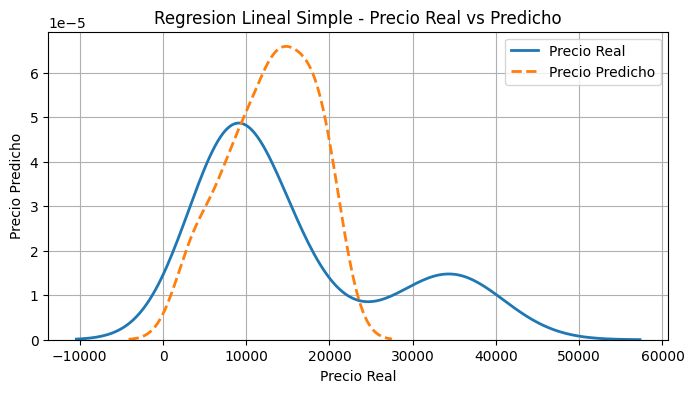

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Regresion Lineal Simple - Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

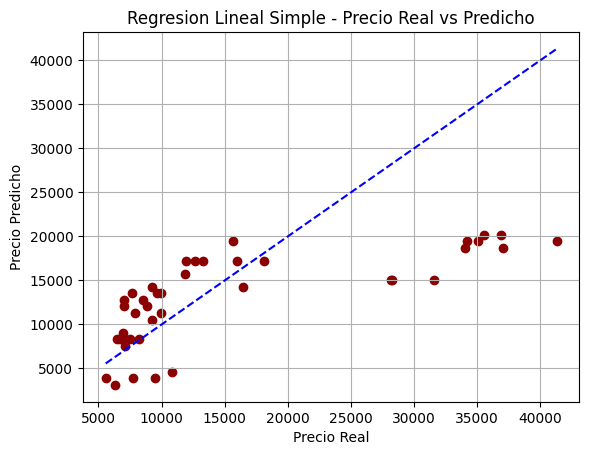

In [ ]:
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') #
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Regresion Lineal Simple - Precio Real vs Predicho")
plt.grid(True)
plt.show()